### -------------------------------------------------
### Hita et al. (2018) – catalytic hydrotreatment of KL
### -------------------------------------------------

In [1]:
import pandas as pd, numpy as np, json
from pathlib import Path

COLUMNS = [
    "DOI","Paper_Title","Provenance","Ref",
    "Process_type","Process_subtype",
    "Feedstock","Family","Tier",
    "T","t","IC","Pressure","Solvent_or_medium","Reactor","Separation_method","Yield_basis",
    "Catalyst","Catalyst_Biomass_ratio","Heating_rate","Stirring_velocity","Water_Biomass_ratio",
    "Lignin","Cellulose_pct","Hemicellulose_pct","Extractives_pct","atmosphere",
    "C","H","O","N","S","Ash","O/C","H/C","HHV_input",
    "B_Y","C_Y","A_Y","G_Y","GW_Y",
    "E_B","E_H","C_B","C_H",
    "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",
    "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
    "Moisture_min","Moisture_max",
    "Lignin_Rich","extra"
]

def _empty_row():
    return {k: np.nan for k in COLUMNS}


def _family(feed:str)->str:
    s = (feed or "").lower()
    if any(x in s for x in ["straw","corn","rice","wheat","soy","herbaceous","tobacco"]): return "Ag residues / Herbaceous"
    if any(x in s for x in ["spruce","pine","fir"]): return "Woody Biomass / Softwood"
    if "poplar" in s or "eucalyptus" in s: return "Woody Biomass / Hardwood"
    if "mix" in s or "blend" in s: return "Woody Biomass / Mixed"
    if any(x in s for x in ["lignin","protobind","alkali lignin","kraft","organosolv"]): return "Pure lignin"
    return "Lignocellulosic / Other"

def _safe_json_load(obj):
    if isinstance(obj, dict): 
        return obj
    if isinstance(obj, str) and obj.strip():
        try:
            return json.loads(obj)
        except Exception:
            return {}
    return {}

def _btw_to_ic(s):
    if s is None: 
        return np.nan
    if isinstance(s, (int, float, np.integer, np.floating)):
        return float(s)
    txt = str(s).strip().replace(",", ".")
    if ':' in txt or '/' in txt:
        for sep in (':','/'):
            if sep in txt:
                a,b = txt.split(sep,1)
                try:
                    a = float(a.strip()); b = float(b.strip())
                    return a/b if b != 0 else np.nan
                except Exception:
                    return np.nan
    try:
        return float(txt)
    except Exception:
        return np.nan

def _oc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(O): return np.nan
    return round((O/16.0)/(C/12.01), 3)

def _hc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(H): return np.nan
    return round((H/1.008)/(C/12.01), 3)

def _isna(v):
    return v is None or (isinstance(v,(float,np.floating)) and np.isnan(v))

def _eq_key(a, b):
    if _isna(a) and _isna(b): 
        return True
    try:
        af, bf = float(a), float(b)
        return abs(af - bf) < 1e-9
    except Exception:
        pass
    return str(a).strip() == str(b).strip()

def _upsert(df, row, keys=("DOI","Feedstock","T","t","IC","Catalyst","Solvent_or_medium","Catalyst_Biomass_ratio")):
    if df.empty:
        return pd.DataFrame([row], columns=row.keys())
    mask = pd.Series(True, index=df.index)
    for k in keys:
        if k not in df.columns:
            df[k] = np.nan
        rv = row.get(k)
        mask &= df[k].apply(lambda cv: _eq_key(cv, rv))
    if mask.any():
        i = mask.idxmax()
        for k,v in row.items():
            if k in df.columns and (_isna(df.at[i,k]) and not _isna(v)):
                df.at[i,k] = v
        return df
    return pd.concat([df, pd.DataFrame([row])], ignore_index=True)

# ---------- builders ----------
def add_feed(
    df, *, doi, paper_title, prov, ref, feedstock,
    C=None,H=None,O=None,N=None,S=None,Ash=None, HHV_input=None,
    lignin=None,cell=None,hemi=None,extract=None, moisture=None, source_note="Feed table/text"
):
    row = _empty_row()
    ex = {
        "provenance": {"doi": doi, "source": [source_note], "role": "feed"}
    }
    row.update(dict(
        DOI=doi, Paper_Title=paper_title, Provenance=prov, Ref=ref,
        Process_type="Hydrothermal", Process_subtype=None,
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        Pressure=None, Solvent_or_medium=None, Reactor=None, Separation_method=None,
        Yield_basis="wt% of dry feedstock",
        C=C,H=H,O=O,N=N,S=S,Ash=Ash, HHV_input=HHV_input,
        Lignin=lignin, Cellulose_pct=cell, Hemicellulose_pct=hemi, Extractives_pct=extract,
        Moisture_min=moisture, Moisture_max=moisture,
        Lignin_Rich=True,
        extra=json.dumps(ex, ensure_ascii=False)
    ))
    return _upsert(df, row, keys=("DOI","Feedstock","Ref"))

def add_or_patch_run(
    df, *,
    doi, paper_title, prov, ref, feedstock,
    T=None, t_min=None, t_h=None, BTW=None, IC=None,
    catalyst=None, cat_wt_pct=None, solvent="Water", reactor=None, sep=None,
    process_subtype=None, yield_basis="wt% of dry feedstock",
    BY=None, CY=None, AY=None, GY=None, GWY=None,
    HHV_bo=None, C_bo=None, H_bo=None, O_bo=None, N_bo=None, S_bo=None,
    HHV_ch=None, C_ch=None, H_ch=None, O_ch=None, N_ch=None, S_ch=None,
    label=None, notes=None, extra=None, atmosphere=None, pressure_text=None,
    stirring_rpm=None, heating_rate=None,
    upsert_keys=None
):
    if t_min is None and t_h is not None:
        t_min = float(t_h)*60.0
    if IC is None and BTW is not None:
        IC = _btw_to_ic(BTW)

    row = _empty_row()
    row.update(dict(
        DOI=doi, Paper_Title=paper_title, Provenance=prov, Ref=ref,
        Process_type="Hydrothermal",
        Process_subtype=(process_subtype or ("Catalytic" if catalyst else "Non-catalytic")),
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        T=(None if T is None else float(T)),
        t=(None if t_min is None else float(t_min)),
        IC=(None if IC is None else float(IC)),
        Pressure=pressure_text if pressure_text else "autogenic",
        Solvent_or_medium=solvent, Reactor=reactor, Separation_method=sep,
        Yield_basis=yield_basis,
        Catalyst=(None if not catalyst else str(catalyst)),
        Catalyst_Biomass_ratio=(None if cat_wt_pct is None else float(cat_wt_pct)/100.0),
        Water_Biomass_ratio=(None if IC is None else round(1.0/float(IC),3)) if IC not in (None,0) else None,
        atmosphere=atmosphere,
        Heating_rate=heating_rate,
        Stirring_velocity=stirring_rpm,

        B_Y=None if BY is None else float(BY),
        C_Y=None if CY is None else float(CY),
        A_Y=None if AY is None else float(AY),
        G_Y=None if GY is None else float(GY),
        GW_Y=None if GWY is None else float(GWY),

        HHV_biooil=None if HHV_bo is None else float(HHV_bo),
        C_biooil=None if C_bo is None else float(C_bo),
        H_biooil=None if H_bo is None else float(H_bo),
        O_biooil=None if O_bo is None else float(O_bo),
        N_biooil=None if N_bo is None else float(N_bo),
        S_biooil=None if S_bo is None else float(S_bo),

        HHV_biochar=None if HHV_ch is None else float(HHV_ch),
        C_biochar=None if C_ch is None else float(C_ch),
        H_biochar=None if H_ch is None else float(H_ch),
        O_biochar=None if O_ch is None else float(O_ch),
        N_biochar=None if N_ch is None else float(N_ch),
        S_biochar=None if S_ch is None else float(S_ch),

        Lignin_Rich=True
    ))
    ex = {"label": label, "notes": notes}
    if extra: ex.update(extra)
    row["extra"] = json.dumps({k:v for k,v in ex.items() if v is not None}, ensure_ascii=False)

    return _upsert(
        df,
        row,
        keys=(upsert_keys or ("DOI","Feedstock","T","t","IC","Catalyst","Catalyst_Biomass_ratio","Solvent_or_medium"))
    )

def _get_ER_pct(r):
    ex = _safe_json_load(r.get("extra"))
    er = ex.get("ER_pct")
    try:
        return float(er) if er is not None else np.nan
    except Exception:
        return np.nan

def finalize(df):
    out = df.copy()
    num_cols = [
        "B_Y","C_Y","A_Y","G_Y","GW_Y",
        "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",
        "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
        "C","H","O","N","S","Ash","T","t","IC","HHV_input"
    ]
    for c in num_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    for i, r in out.iterrows():
        BY, CY = r.get("B_Y"), r.get("C_Y")
        HHV_bo, HHV_ch = r.get("HHV_biooil"), r.get("HHV_biochar")
        C_bo, H_bo, O_bo, N_bo, S_bo = r.get("C_biooil"), r.get("H_biooil"), r.get("O_biooil"), r.get("N_biooil"), r.get("S_biooil")
        C_ch, H_ch, O_ch, N_ch, S_ch = r.get("C_biochar"), r.get("H_biochar"), r.get("O_biochar"), r.get("N_biochar"), r.get("S_biochar")

        Cf, Hf, Of = r.get("C"), r.get("H"), r.get("O")
        out.at[i, "O/C"] = _oc(Cf, Hf, Of)
        out.at[i, "H/C"] = _hc(Cf, Hf, Of)

        BY_ok = pd.notna(BY) and 0 <= BY <= 100
        CY_ok = pd.notna(CY) and 0 <= CY <= 100

        out.at[i, "E_B"] = (BY/100.0)*HHV_bo if BY_ok and pd.notna(HHV_bo) else np.nan
        out.at[i, "E_H"] = (CY/100.0)*HHV_ch if CY_ok and pd.notna(HHV_ch) else np.nan

        out.at[i, "C_B"] = (BY/100.0)*(C_bo/100.0) if BY_ok and pd.notna(C_bo) else np.nan
        out.at[i, "C_H"] = (CY/100.0)*(C_ch/100.0) if CY_ok and pd.notna(C_ch) else np.nan

        ex = _safe_json_load(r.get("extra"))
        qa = ex.setdefault("QA", {})

        elems_bo = [C_bo, H_bo, O_bo, N_bo, S_bo]
        if any(pd.notna(x) for x in elems_bo):
            qa["biooil_elem_sum_pct"] = round(float(np.nansum([x for x in elems_bo if pd.notna(x)])), 2)

        elems_ch = [C_ch, H_ch, O_ch, N_ch, S_ch]
        if any(pd.notna(x) for x in elems_ch):
            qa["biochar_elem_sum_pct"] = round(float(np.nansum([x for x in elems_ch if pd.notna(x)])), 2)

        parts = [x for x in [BY, CY, r.get("A_Y"), r.get("G_Y")] if pd.notna(x)]
        if parts:
            s = float(np.nansum(parts))
            qa["mass_closure_sum_pct"] = round(s, 2)
            qa["Unassigned_or_over_pct"] = round(100.0 - s, 2)

        out.at[i, "extra"] = json.dumps(ex, ensure_ascii=False)

    return out

def propagate_feed_chem(df):
    out = df.copy()
    chem_cols = ["C","H","O","N","S","Ash","HHV_input","Cellulose_pct","Hemicellulose_pct","Lignin","Extractives_pct"]

    feed_rows = {}
    for feed, g in out.groupby("Feedstock", dropna=False):
        # prefer rows explicitly tagged as feed in extra.provenance.role
        def _is_feed_row(row):
            ex = _safe_json_load(row.get("extra"))
            role = (ex.get("provenance") or {}).get("role")
            return isinstance(role, str) and role.lower() == "feed"

        g1 = g[g.apply(_is_feed_row, axis=1)]
        if not g1.empty:
            pick = g1.iloc[0]
        else:
            # fallback: first row that has C/H/O
            m_chem = g[["C","H","O"]].notna().all(axis=1) if set(["C","H","O"]).issubset(g.columns) else pd.Series(False, index=g.index)
            pick = g[m_chem].iloc[0] if m_chem.any() else None

        if pick is not None:
            feed_rows[feed] = pick

    for i, r in out.iterrows():
        feed = r.get("Feedstock")
        pick = feed_rows.get(feed)
        if pick is None:
            continue
        for k in chem_cols:
            if k in out.columns and pd.isna(out.at[i, k]):
                out.at[i, k] = pick.get(k)

    out["O/C"] = [_oc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out["H/C"] = [_hc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    return out

def propagate_and_clean(df):
    import math
    out = propagate_feed_chem(df.copy())

    out["O/C"] = [_oc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out["H/C"] = [_hc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]

    out_cols = ["B_Y","C_Y","A_Y","G_Y","HHV_biooil","C_biooil","HHV_biochar","C_biochar"]
    has_out = out[out_cols].notna().any(axis=1)
    return out.loc[has_out].copy()

def attach_biochar_props(df, records):
    out = df.copy()
    for rec in records:
        m = (out["Feedstock"].astype(str)==str(rec["feedstock"])) & (out["T"]==float(rec["T"])) & (out["t"]==float(rec["t"]))
        for i in out[m].index:
            out.at[i,"HHV_biochar"] = rec.get("HHV_biochar", out.at[i,"HHV_biochar"])
            out.at[i,"C_biochar"] = rec.get("C_biochar", out.at[i,"C_biochar"])
            ex = _safe_json_load(out.at[i,"extra"])
            ex.setdefault("provenance_updates", []).append({k:rec[k] for k in ["ref"] if k in rec})
            out.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)
    return finalize(out)


df = pd.DataFrame(columns=COLUMNS)


In [2]:

doi  = "10.1016/j.fuproc.2018.06.018"
paper_title = ("Biobased chemicals from the catalytic depolymerization of "
               "Kraft lignin using supported noble metal-based catalysts")
ref  = "Hita_2018_KL_noble_metals"
feed = "Indulin AT Kraft lignin"


try:
    df
except NameError:
    df = pd.DataFrame(columns=COLUMNS)

df = add_feed(
    df,
    doi=doi,
    paper_title=paper_title,
    prov=("Feed properties imputed from Figueirêdo 2020 (SEF, KL elemental) "
          "+ Olgun 2023 (Indulin AT ash & Klason lignin)"),
    ref=ref,
    feedstock=feed,
    C=62.2,
    H=6.0,
    N=0.75,
    O=29.8,
    S=1.2,
    Ash=2.02,          # Indulin AT ash ~2 wt%
    HHV_input=None,
    lignin=88.8,       # Klason lignin (purity proxy)
    cell=None,
    hemi=None,
    extract=None,
    moisture=None,
    source_note=("Indulin AT properties imputed from external characterization "
                 "studies: elemental (KL) + ash & Klason lignin (Indulin AT)")
)


T_reaction   = 450.0      # °C
t_h          = 4.0        # h
heating_rate = 10.0       # °C/min
stirring_rpm = 1200.0
IC_val       = np.nan     # no water; neat lignin under H2
solvent_medium = "Neat lignin (no solvent); H2 gas"
pressure_txt   = "100 bar H2 (initial), batch; >100 bar autogenic at 450°C"
yield_basis    = "wt% on lignin intake"

catalysts = [
    "Ru/C",
    "Ru/Al2O3",
    "Pt/C",
    "Pt/Al2O3",
    "Pd/C",
    "Pd/Al2O3",
    "Rh/C",
    "Rh/Al2O3",
]

data = {
    # === Table 2, wt% on lignin intake ===
    "organic_phase": [36.2, 30.4, 26.3, 40.3, 29.7, 37.5, 39.2, 41.5],
 
    "B_Y":           [31.7, 26.5, 21.5, 35.2, 25.1, 33.3, 33.8, 36.3],
    "A_Y":           [20.9, 21.3, 20.1, 21.0, 21.4, 20.1, 22.0, 20.5],  # aqueous phase
    "G_Y":           [15.0, 13.5, 12.3, 14.4, 13.3, 15.2, 14.6, 14.5],  # gas
    "C_Y":           [19.4, 25.6, 32.8, 17.5, 25.8, 20.6, 17.7, 16.5],  # solid residue
    "mass_balance":  [91.6, 90.7, 91.5, 93.5, 90.3, 93.4, 93.5, 92.9],
    "C_balance":     [90.8, 86.9, 96.2, 89.1, 87.9, 90.2, 95.3, 88.3],

    "lignin_oil": [31.7, 26.5, 21.5, 35.2, 25.1, 33.3, 33.8, 36.3],
    "dcm_sol":    [4.2, 3.6, 4.6, 4.6, 4.3, 3.8, 4.8, 5.0],
    "acet_sol":   [0.3, 0.3, 0.2, 0.5, 0.3, 0.4, 0.6, 0.2],

    "C_bo": [81.8, 82.0, 80.2, 81.7, 79.4, 79.8, 81.7, 81.3],
    "H_bo": [8.1, 7.6, 7.8, 7.4, 7.6, 7.5, 7.8, 7.5],
    "O_bo": [9.7, 9.6, 11.2, 10.1, 12.2, 12.0, 9.7, 10.5],
    "N_bo": [0.3, 0.6, 0.7, 0.7, 0.7, 0.6, 0.7, 0.7],
    "S_bo": [0.01, 0.10, 0.15, 0.05, 0.01, 0.06, 0.07, 0.01],  # last "<0.01" ~ 0.01
}

for i, cat in enumerate(catalysts):
    extra = {
        "provenance": {
            "doi": doi,
            "source": ["Table 2 (product yields, mass & C balances, oil elemental)"],
            "role": "run",
        },

        "organic_phase_yield_pct":        data["organic_phase"][i],
        "mass_balance_pct":              data["mass_balance"][i],
        "carbon_balance_pct":            data["C_balance"][i],
        "lignin_oil_yield_pct":          data["lignin_oil"][i],
        "DCM_solubles_yield_pct":        data["dcm_sol"][i],
        "acetone_solubles_yield_pct":    data["acet_sol"][i],
    }

    df = add_or_patch_run(
        df,
        doi=doi,
        paper_title=paper_title,
        prov="Table 2 (yields, balances, oil composition)",
        ref=ref,
        feedstock=feed,
        T=T_reaction,
        t_h=t_h,
        IC=IC_val,
        catalyst=cat,
        cat_wt_pct=5.0,  # 0.75 g catalyst / 15 g KL = 5 wt%
        solvent=solvent_medium,
        reactor="100 mL Parr autoclave, Rushton turbine",
        sep="Decantation + DCM and acetone wash; phase separation as in Fig. 1",
        process_subtype="Hydrotreatment",
        yield_basis=yield_basis,
        BY=data["B_Y"][i],     
        CY=data["C_Y"][i],
        AY=data["A_Y"][i],
        GY=data["G_Y"][i],
        HHV_bo=None,
        C_bo=data["C_bo"][i],
        H_bo=data["H_bo"][i],
        O_bo=data["O_bo"][i],
        N_bo=data["N_bo"][i],
        S_bo=data["S_bo"][i],
        HHV_ch=None,
        C_ch=None,
        H_ch=None,
        O_ch=None,
        N_ch=None,
        S_ch=None,
        label=f"{ref} | {cat}",
        notes=("Hydrotreatment at 450°C, 4 h, 100 bar H2 initial; "
               "organic phase = lignin oil + DCM + acetone solubles."),
        extra=extra,
        atmosphere="H2, 100 bar initial, stirred 1200 rpm",
        pressure_text=pressure_txt,
        stirring_rpm=stirring_rpm,
        heating_rate=heating_rate,
    )


df_hita_2018 =propagate_feed_chem(df)
df_hita_2018 = finalize(df_hita_2018)
df_hita_2018 = propagate_and_clean(df_hita_2018)



df_hita_2018[df_hita_2018["Ref"] == ref]


csv_path = Path("./CSVs/Hita_2018_KraftLignin_NobleMetalCats.csv")


df_hita_2018.to_csv(csv_path, index=False)

In [3]:
n_EB =  df_hita_2018["E_B"].notna().sum()
n_CB = df_hita_2018["C_B"].notna().sum()
n_EH = df_hita_2018["E_H"].notna().sum()
n_CH = df_hita_2018["C_H"].notna().sum()
print(f"E_H filled rows: {n_EH} | C_H filled rows: {n_CH}")
print(f"E_B filled rows: {n_EB} | C_B filled rows: {n_CB}")


E_H filled rows: 0 | C_H filled rows: 0
E_B filled rows: 0 | C_B filled rows: 8


E_H > 25.0 MJ/kg: 0 rows
E_B > 25.0 MJ/kg: 0 rows
B_Y outside [0,100]: 0 rows
C_Y outside [0,100]: 0 rows
C_B > 0.60 (fraction): 0 rows
C_H > 0.65 (fraction): 0 rows
HHV_input < 12 MJ/kg: 0 rows
H/C outside ~[0.8,1.9]: 0 rows
O/C outside ~[0.35,0.95]: 0 rows
No data to plot for E_B.
No data to plot for E_H.
No data to plot for C_B.
No data to plot for C_H.
Mass-balance check (B_Y+C_Y+A_Y+G_Y ≈ 100): 8 violations out of 8 rows


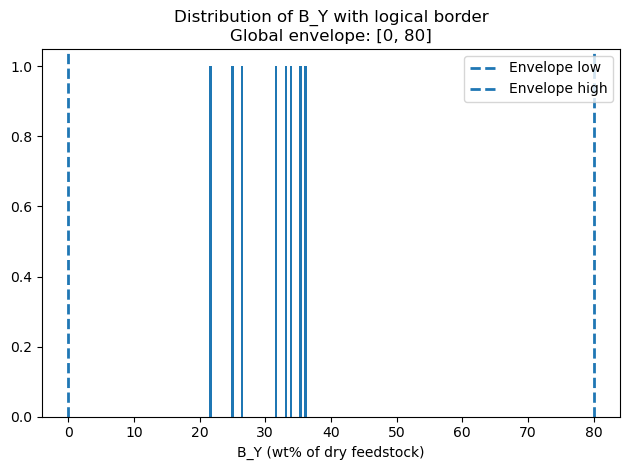

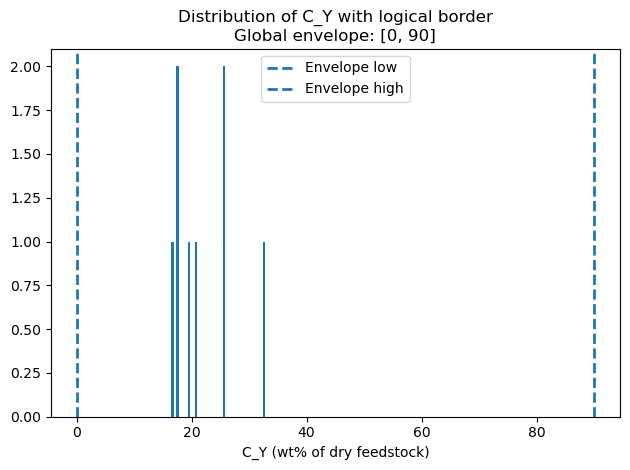

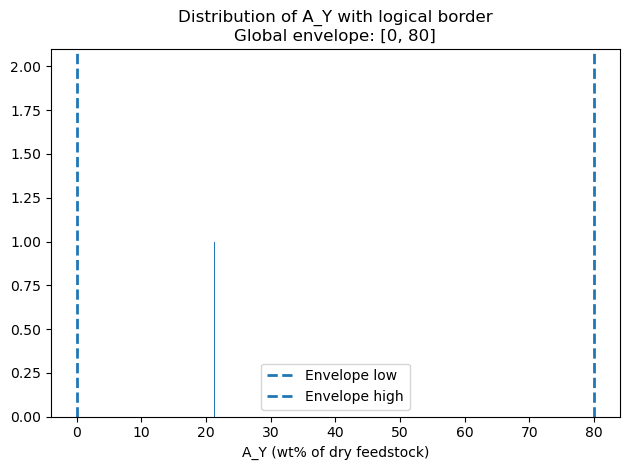

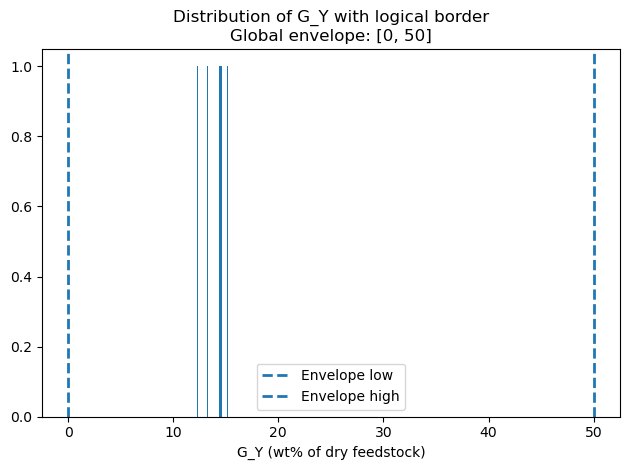

In [5]:
import importlib.util, pathlib, sys

mod_path = pathlib.Path("../../modules/qa_envelopes.py").resolve() 
spec = importlib.util.spec_from_file_location("qa_envelopes", str(mod_path))
qa_envelopes = importlib.util.module_from_spec(spec)
sys.modules["qa_envelopes"] = qa_envelopes
spec.loader.exec_module(qa_envelopes)

qa_envelopes.run_basic_qc(df)
qa_envelopes.plot_energy_carbon_envelopes(df)
qa_envelopes.plot_yield_envelopes(df)